In [1]:
%load_ext autoreload
%autoreload 2

# 1. Import CellRefiner and packages

In [ ]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import scanpy as sc
# import sys
# sys.path.append('..')
import cellrefiner as cr

['/home/kxy/cellrefiner/cellrefiner_repo/tutorials/../cellrefiner']

# 2. Load Data

The paired datasets here are from Visium spatial transcriptomic data and scRNA-seq samples of the mouse cortex available via the squidpy package.

In [3]:
import squidpy as sq
adata_st = sq.datasets.visium_fluo_adata_crop()
adata_st = adata_st[adata_st.obs.cluster.isin([f"Cortex_{i}" for i in np.arange(1, 5)])].copy()
adata_sc = sq.datasets.sc_mouse_cortex()
print(adata_st)
print(adata_sc)

/home/kxy/miniconda3/envs/cr_39/lib/python3.9/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/kxy/miniconda3/envs/cr_39/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


AnnData object with n_obs × n_vars = 324 × 16562
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'MT', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
AnnData object with n_obs × n_vars = 21697 × 36826
    obs: 'sample_name', 'organism', 'donor_sex', 'cell_class', 'cell_subclass', 'cell_clu

Load the mouse ligand-receptor database from local path, originally sourced from CellChat

In [4]:
db_lr = cr.pp.ligand_receptor_database(species='mouse')
scale = adata_st.uns['spatial']['V1_Adult_Mouse_Brain_Coronal_Section_2']['scalefactors']['spot_diameter_fullres']
adata_cr = cr.pp.spatial_mapping(adata_st,adata_sc,db_lr,scale=scale,cluster_key_sc = 'cell_subclass',n_rank_gene=100)
print(adata_cr)

/home/kxy/miniconda3/envs/cr_39/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/kxy/miniconda3/envs/cr_39/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:459: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/kxy/miniconda3/envs/cr_39/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/home/kxy/miniconda3/envs/cr_39/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: divide by zero encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/kxy/miniconda3/envs/cr_39/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:458: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / 

AnnData object with n_obs × n_vars = 1620 × 36826
    obs: 'sample_name', 'organism', 'donor_sex', 'cell_class', 'cell_subclass', 'cell_cluster', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cell_class_colors', 'cell_subclass_colors', 'hvg', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


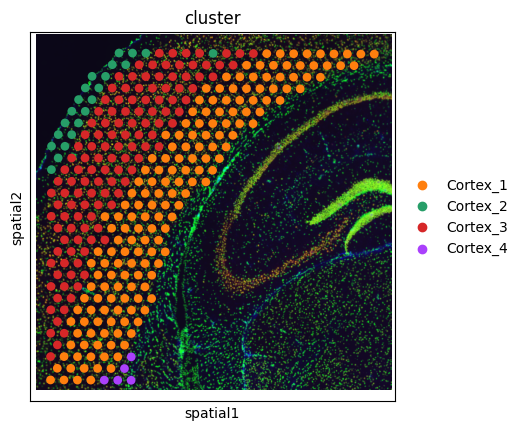

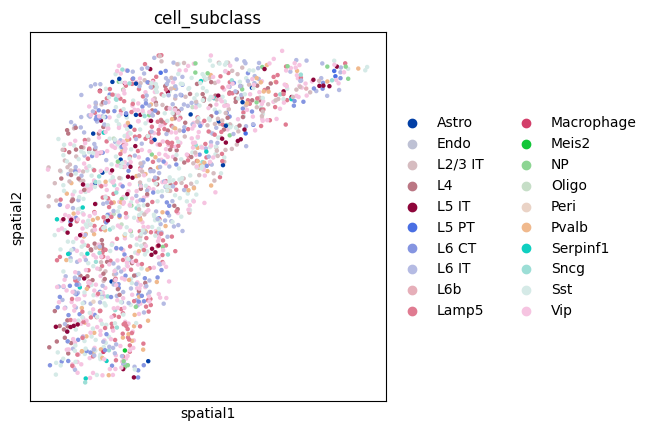

In [5]:
sc.pl.spatial(adata_st, color = 'cluster')
sc.pl.spatial(adata_cr, color = 'cell_subclass',spot_size = 100)

In [6]:
sem = cr.tl.cell_shape_modeling(adata_cr,cluster_key = 'cell_subclass')

Simulation:   0%|          | 0/2000 [00:00<?, ?it/s]/home/kxy/miniconda3/envs/cr_39/lib/python3.9/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 85 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
Simulation: 100%|██████████| 2000/2000 [00:27<00:00, 73.85it/s]


add .obsp['contacts'], .uns['contacts']
Computing alpha-shape with parameters: alpha=None, ns=10, r=1.2


Processing Cell Shapes: 100%|██████████| 1620/1620 [00:14<00:00, 110.98it/s]


<Axes: >

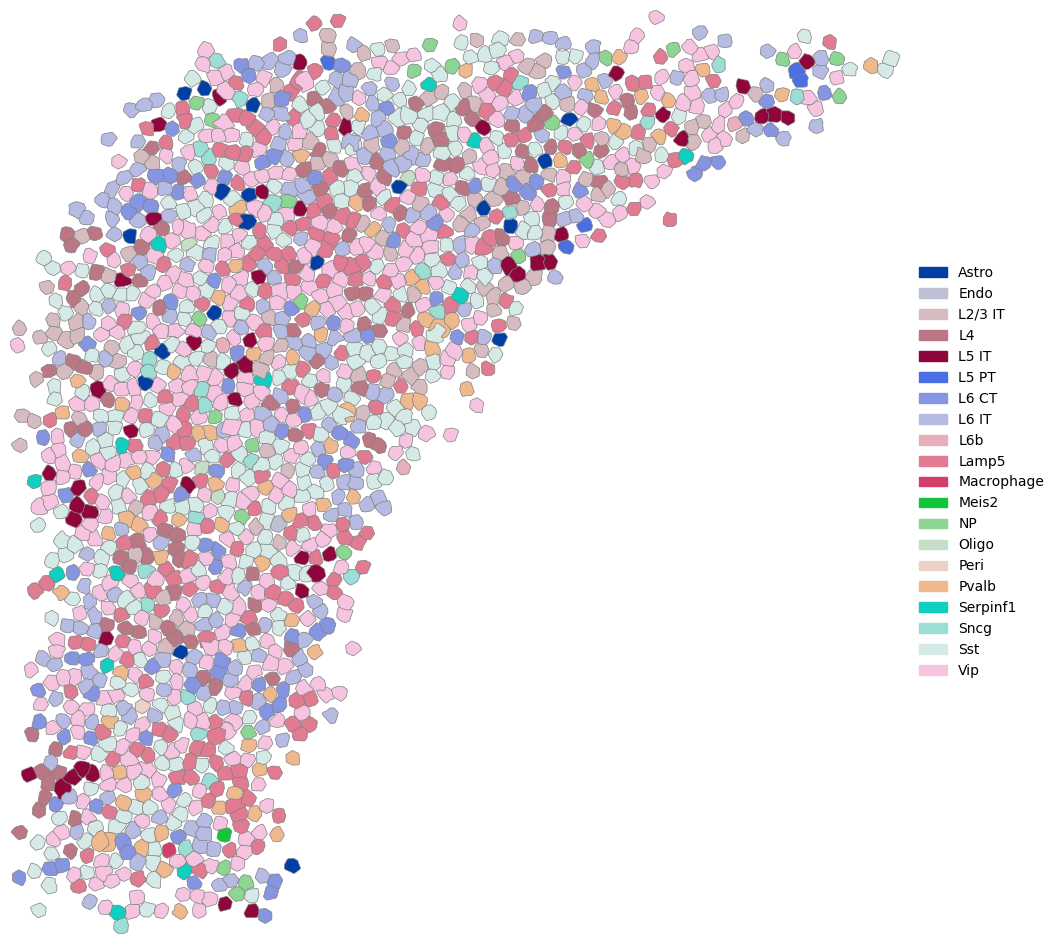

In [7]:
fig,ax=plt.subplots(figsize=(12,12))
cr.pl.plot_cell_shape(sem,ax=ax,boundary_color='gray',boundary_width=0.5)

In [9]:
db_lr = cr.pp.ligand_receptor_database()
db_lr = cr.pp.filter_lr_database(db_lr,adata_cr, min_cell_pct=0.01)
cr.tl.contact_communication(db_lr, adata = adata_cr)

add .uns['contact_signal_info']
add .obsm['sender_signal'], .obsm['receiver_signal']


<Axes: >

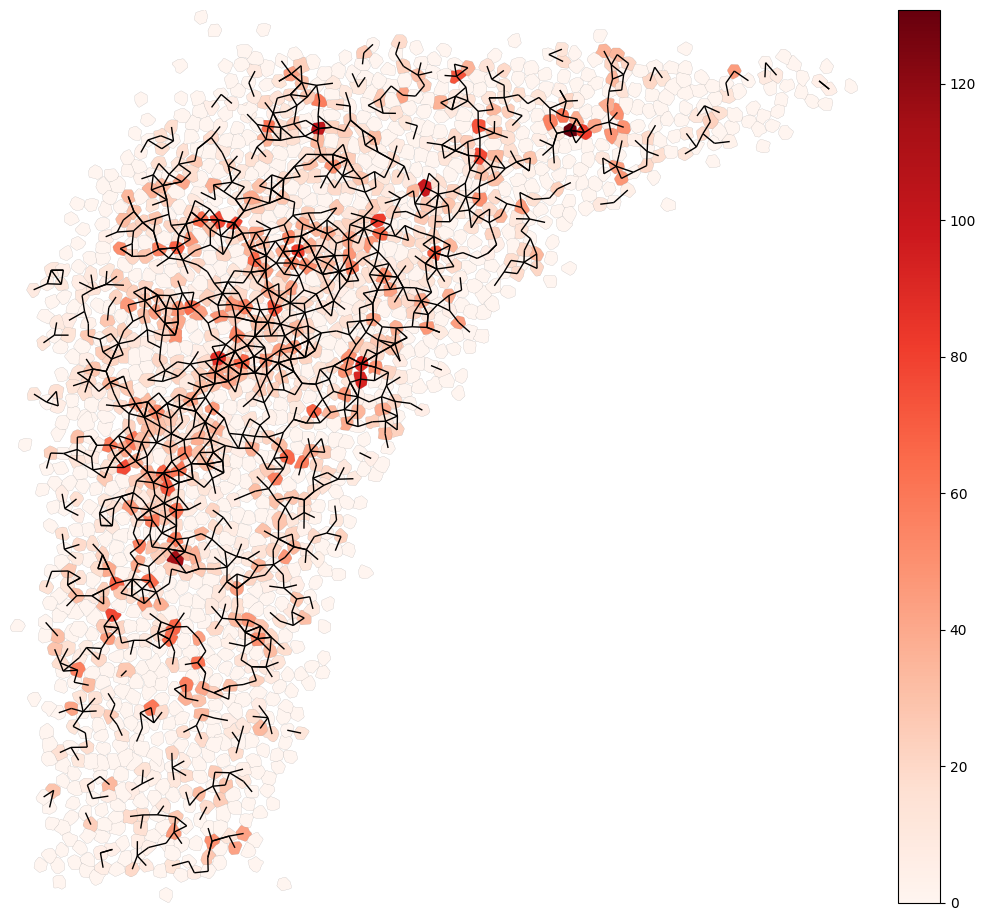

In [26]:
fig,ax=plt.subplots(figsize=(12,12))
cr.pl.plot_cell_shape(sem,ax=ax,vis_key='NOTCH',boundary_color='gray',boundary_width=0.1)
cr.pl.plot_contact_signal(sem,ax=ax,signal = 'NOTCH')

<Axes: >

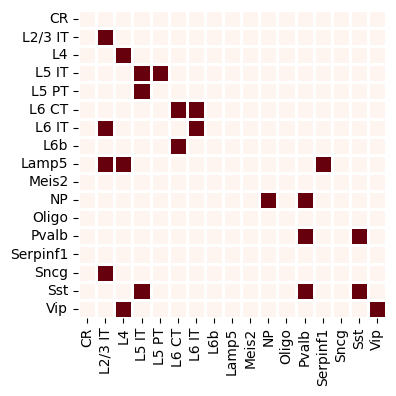

In [27]:
cr.tl.cluster_communication(adata_cr,cluster_key = 'cell_subclass',signal = 'NOTCH')
fig,ax=plt.subplots(figsize=(6,4))
sns.heatmap(adata_cr.uns[f'cell_subclass-NOTCH']['communication_pvalue']<0.05,square=True,linewidths=1,ax=ax,cmap='Reds',cbar=False)

In [ ]:
# plot all pathway
summary = 'sender'
for pth in adata_cr.uns['contact_signal_info']['pathway']:
    fig,ax=plt.subplots(figsize=(12,12))
    if summary == 'cell':
        cr.pl.plot_cell_shape(sem,boundary_color='gray',boundary_width=0.4,ax=ax,enable_colorbar=False,enable_legend=True)
    else:
        cr.pl.plot_cell_shape(sem,vis_key=pth,summary=summary,boundary_color='gray',cmap_name='Reds',boundary_width=0.4,ax=ax,enable_colorbar=True)
    cr.pl.plot_contact_signal(sem,signal=pth,line_color = 'k', line_width=0.8, ax=ax, line_alpha=0.8)#r.dot(l.T)*
    ax.set_axis_off()
    fig.savefig(f"{pth}_{summary}.png", dpi=500, bbox_inches='tight')
    plt.close(fig)

In [13]:
for sig_key in adata_cr.uns['contact_signal_info']['pathway']:
    cr.tl.cluster_communication(adata_cr,'cell_subclass',sig_key)

In [14]:
# cluster-level
for pth in adata_cr.uns['contact_signal_info']['pathway']:
    fig,ax=plt.subplots(figsize=(6,4))
    sns.heatmap(adata_cr.uns[f'cell_subclass-{pth}']['communication_pvalue']<0.05,square=True,linewidths=1,ax=ax,cmap='Reds',cbar=False)
    fig.savefig(f"{pth}_significance.png", dpi=500, bbox_inches='tight')
    plt.close(fig)